<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/Carena_EGN_Fig1368_verified.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carena EGN Fig. 1, 3, 6, 8 — self-contained validation report

Upload this notebook to Colab and run all cells. No unpublished GitHub files are required.

# Carena EGN validation — paper Figs. 1, 3, 6 and 8

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/2026_KICS_Fall_10/EGN_modulation_Carena_Fig1368_validation_colab.ipynb)

This notebook compares the executable `EGN_modulation.py` implementation with the supplied Carena *et al.* paper, **“EGN model of non-linear fiber propagation,” Optics Express 22, 16335 (2014)**. It evaluates the same normalised coefficient

\[
\eta = P_{\rm ch}^{-3}\int_{-R_s/2}^{R_s/2}G(f)\,df,
\]

and reports both signed/absolute dB error and the equivalent linear NLI relative error. No curve fitting, offset fitting, or post-hoc parameter tuning is used.

## What is being compared

| Paper figure | Code quantity | Carena equations | Channels |
|---|---|---|---:|
| Fig. 1 | SCI GN and SCI EGN | Eqs. (5)–(13) | 1 |
| Fig. 3 | GN without SCI, XPM, XCI-EGN | Eqs. (18), (20), (22) | 3 |
| Fig. 6 | GN without SCI, XPM, XMCI-EGN | Eqs. (18), (22), (23)–(28) | 3 |
| Fig. 8 | GN without SCI, XPM, XMCI-EGN | Eqs. (18), (22), (28), Appendices A–B | 9 |

The paper's analytic EGN derivation assumes rectangular spectra. The paper's red simulation curves used a 0.05 raised-cosine roll-off; those red curves are therefore an external SSFM reference, not a second code run. The code uses the paper's rectangular analytic assumption for theory-to-theory comparisons. `Nspan={1,2,5,10,20,50}` are reported in the table/markers; the grey/dashed paper curve is digitised from the supplied PDF vector artwork at all 1–50 span points.

In [1]:
# Self-contained snapshot: no GitHub dependency. Extract only into a new directory.
from pathlib import Path
import sys, json, base64, tempfile
BASE = Path(tempfile.mkdtemp(prefix="carena_snapshot_"))
PAYLOAD = {'EGN_modulation.py': '...', 'gn_integral_general.py': '...', 'gn_integral_general_modulation.py': '...', 'carena_fig1368_reference.json': '...', 'carena_fig1368_code_cache.json': '...', 'carena_fig1_overlay.png': '...', 'carena_fig3_overlay.png': '...', 'carena_fig6_overlay.png': '...', 'carena_fig8_overlay.png': '...', 'carena_fig1368_error.png': '...'}
for name, encoded in PAYLOAD.items():
    (BASE/name).write_bytes(base64.b64decode(encoded))
sys.path.insert(0, str(BASE))
print("Using embedded snapshot", BASE)


Using embedded snapshot /tmp/carena_snapshot_ujem9i_p


In [2]:
import math, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
import EGN_modulation as egn
print("FULL_WDM_EGN_IMPLEMENTED =", egn.FULL_WDM_EGN_IMPLEMENTED)
print("Phi=1 backward compatibility:", egn.egn_backward_compat_self_test())
print("SCI sanity:", egn.egn_sci_self_test(sobol_power=8, frequency_order=32, receiver_points=3)["passed"])

FULL_WDM_EGN_IMPLEMENTED = True
Phi=1 backward compatibility: {'passed': True, 'max_relative_error': 0.0, 'tolerance': 1e-10}
SCI sanity: True


In [3]:
REF = json.loads((BASE / "carena_fig1368_reference.json").read_text())
CACHE = json.loads((BASE / "carena_fig1368_code_cache.json").read_text())
NSPAN = np.asarray(REF["nspan"], dtype=int)
SELECTED = np.asarray(CACHE["nspan"], dtype=int)
FIBERS = ("SMF", "NZDSF", "LS")
FIG_CONFIG = {
    "Fig1": (1, {"GN": "sci_gn", "EGN": "sci"}),
    "Fig3": (3, {"GN": "gn_no_sci", "XPM": "xpm", "EGN_XCI": "xci"}),
    "Fig6": (3, {"GN": "gn_no_sci", "XPM": "xpm", "EGN_XMCI": "xmci"}),
    "Fig8": (9, {"GN": "gn_no_sci", "XPM": "xpm", "EGN_XMCI": "xmci"}),
}

## Paper parameters used by the evaluator

All four figures use PM-QPSK, 32 GBd, 100 km spans, \(\alpha=0.22\) dB/km, 1550 nm, and 1.05\(R_s\)=33.6 GHz spacing for the WDM plots. Fiber parameters are SMF \((D,\gamma)=(16.7,1.3)\), NZDSF \((3.8,1.5)\), and LS \((-1.8,2.2)\) in the paper's units. The cached run uses \(-3\) dBm/channel, quadrature order 48, 7 receiver points, and 64-point longitudinal quadrature. Change `RUN_RECOMPUTE=True` below to run the same calculation in Colab.

In [4]:
# Optional full recomputation. The default uses the checked-in cache so the
# report opens immediately; no fitted values are hidden in the cache.
RUN_RECOMPUTE = False
NSPAN_RUN = [1, 2, 5, 10, 20, 50]
FIBERS_PARAM = {"SMF": (16.7, 1.3), "NZDSF": (3.8, 1.5), "LS": (-1.8, 2.2)}

def recompute_carena():
    out = {"nspan": NSPAN_RUN, "fibers": {}}
    for nch in (1, 3, 9):
        out["fibers"][str(nch)] = {}
        for fiber, (D, gamma) in FIBERS_PARAM.items():
            rows = []
            for nspan in NSPAN_RUN:
                system = egn.WDMSystem.equispaced(nch, 33.6, 32.0, -3.0,
                    pulse_shape="rect", rolloff=0.0)
                spans = [egn.Span(100.0, 0.22, gamma, D_ps_nm_km=D)
                         for _ in range(nspan)]
                r = egn.carena_egn_eta(
                    system, spans, nch // 2, modulation="QPSK",
                    component="sci" if nch == 1 else "xmci",
                    receiver_points=7, quadrature_order=48,
                    z_quadrature_order=64)
                rows.append({"nspan": nspan, "eta_all_db": r["eta_all_db"]})
            out["fibers"][str(nch)][fiber] = rows
    return out

if RUN_RECOMPUTE:
    CACHE = recompute_carena()
    print("recomputed")

### Optional quadrature audit (not a fit)

This cell is disabled by default. If enabled, it evaluates one representative SMF, 50-span case at several quadrature orders. The comparison table below is never used to alter the cached result; it is only a numerical-convergence diagnostic.

In [5]:
RUN_CONVERGENCE_AUDIT = False
if RUN_CONVERGENCE_AUDIT:
    system = egn.WDMSystem.equispaced(3, 33.6, 32.0, -3.0,
        pulse_shape="rect", rolloff=0.0)
    spans = [egn.Span(100.0, 0.22, 1.3, D_ps_nm_km=16.7) for _ in range(50)]
    audit = []
    for q in (24, 32, 48, 64):
        r = egn.carena_egn_eta(system, spans, 1, component="xmci",
            receiver_points=7, quadrature_order=q, z_quadrature_order=64)
        audit.append({"quadrature_order": q, **r["eta_all_db"]})
    display(pd.DataFrame(audit).round(5))

In [6]:
# Build one long error table. Relative error is computed in linear NLI,
# while dB error is the directly plotted vertical difference.
rows = []
for fig, (nch, mapping) in FIG_CONFIG.items():
    for fiber in FIBERS:
        paper = REF["figures"][fig]["curves"][fiber]
        code = {int(r["nspan"]): r["eta_all_db"] for r in CACHE["fibers"][str(nch)][fiber]}
        for label, key in mapping.items():
            for nspan in SELECTED:
                pi = int(np.where(NSPAN == nspan)[0][0])
                p, c = float(paper[label][pi]), float(code[int(nspan)][key])
                d = c - p
                rows.append({"Fig": fig, "Fiber": fiber, "Curve": label,
                             "Nspan": int(nspan), "Paper [dB]": p, "Code [dB]": c,
                             "Signed error [dB]": d, "Abs error [dB]": abs(d),
                             "Relative error [%]": abs(10**(d/10)-1)*100})
detail = pd.DataFrame(rows)
summary = (detail.groupby(["Fig", "Fiber", "Curve"], as_index=False)
           .agg(points=("Nspan", "size"),
                mean_abs_db=("Abs error [dB]", "mean"),
                max_abs_db=("Abs error [dB]", "max"),
                mean_relative_pct=("Relative error [%]", "mean"),
                max_relative_pct=("Relative error [%]", "max")))
display(summary.round(4))

,Fig,Fiber,Curve,points,mean_abs_db,max_abs_db,mean_relative_pct,max_relative_pct
0,Fig1,LS,EGN,6,0.0420,0.1298,0.9627,2.9443
1,Fig1,LS,GN,6,0.1113,0.1720,2.5277,3.8832
2,Fig1,NZDSF,EGN,6,0.1403,0.2778,3.2996,6.6061
3,Fig1,NZDSF,GN,6,0.0709,0.1603,1.6135,3.6237
4,Fig1,SMF,EGN,6,0.2091,0.8329,5.1650,21.1406
5,Fig1,SMF,GN,6,0.0326,0.1210,0.7448,2.7474
6,Fig3,LS,EGN_XCI,6,0.1351,0.3622,3.2145,8.6982
7,Fig3,LS,GN,6,0.0496,0.1179,1.1358,2.6776
8,Fig3,LS,XPM,6,0.1558,0.3065,3.6921,7.3121
9,Fig3,NZDSF,EGN_XCI,6,0.0602,0.1818,1.3973,4.2750


## Overlays: paper curve and executable code values

Dashed lines are the paper vector-digitised curves; coloured markers/solid lines are the values returned by `EGN_modulation.carena_egn_eta`. The red paper SIM line is retained for context only—the code does not claim to run SSFM.

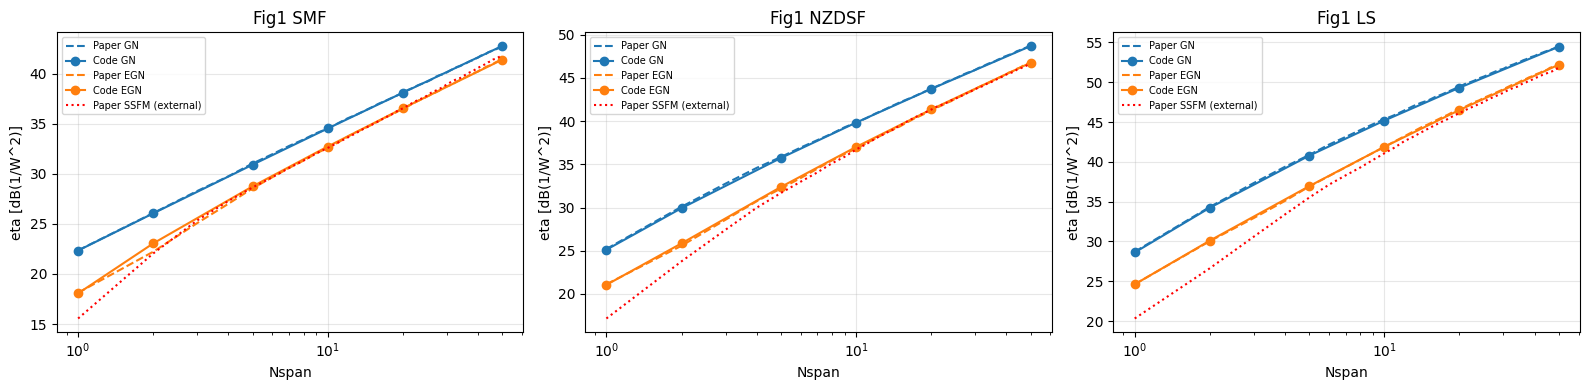

In [7]:
# Dynamic plot: reflects CACHE after RUN_RECOMPUTE, not a stale PNG.
fig_name = 'Fig1'
nch, mapping = FIG_CONFIG[fig_name]
fig, axes = plt.subplots(1,3,figsize=(16,4))
for ax, fiber in zip(axes,FIBERS):
    paper = REF['figures'][fig_name]['curves'][fiber]
    for label in mapping:
        line, = ax.plot(NSPAN,paper[label],'--',label='Paper '+label)
        d = detail[(detail.Fig==fig_name)&(detail.Fiber==fiber)&(detail.Curve==label)]
        ax.plot(d['Nspan'],d['Code [dB]'],'o-',color=line.get_color(),label='Code '+label)
    ax.plot(NSPAN,paper['SIM'],':',color='red',label='Paper SSFM (external)')
    ax.set(xscale='log',xlabel='Nspan',ylabel='eta [dB(1/W^2)]',title=fig_name+' '+fiber)
    ax.grid(alpha=.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


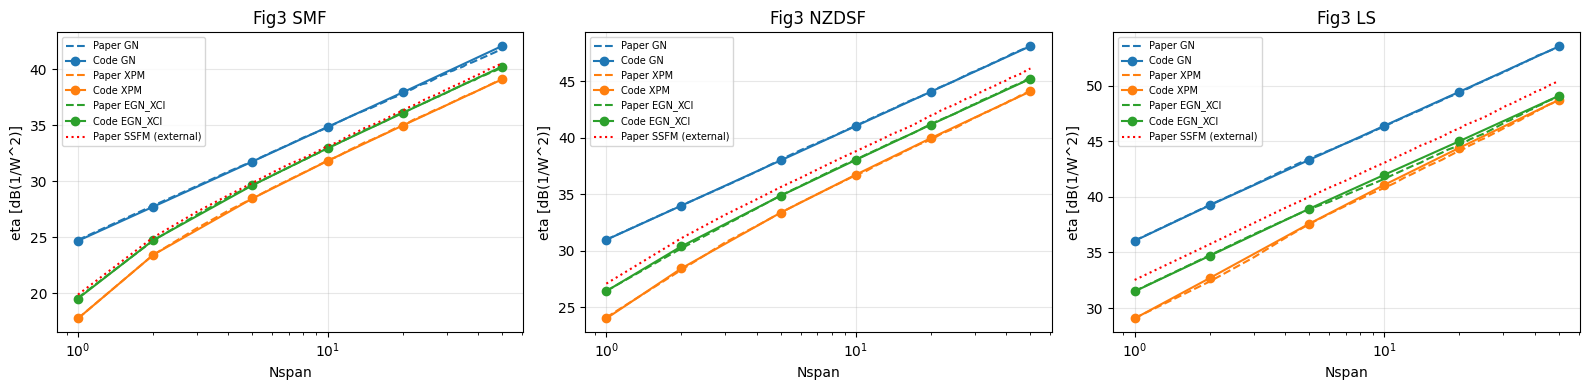

In [8]:
# Dynamic plot: reflects CACHE after RUN_RECOMPUTE, not a stale PNG.
fig_name = 'Fig3'
nch, mapping = FIG_CONFIG[fig_name]
fig, axes = plt.subplots(1,3,figsize=(16,4))
for ax, fiber in zip(axes,FIBERS):
    paper = REF['figures'][fig_name]['curves'][fiber]
    for label in mapping:
        line, = ax.plot(NSPAN,paper[label],'--',label='Paper '+label)
        d = detail[(detail.Fig==fig_name)&(detail.Fiber==fiber)&(detail.Curve==label)]
        ax.plot(d['Nspan'],d['Code [dB]'],'o-',color=line.get_color(),label='Code '+label)
    ax.plot(NSPAN,paper['SIM'],':',color='red',label='Paper SSFM (external)')
    ax.set(xscale='log',xlabel='Nspan',ylabel='eta [dB(1/W^2)]',title=fig_name+' '+fiber)
    ax.grid(alpha=.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


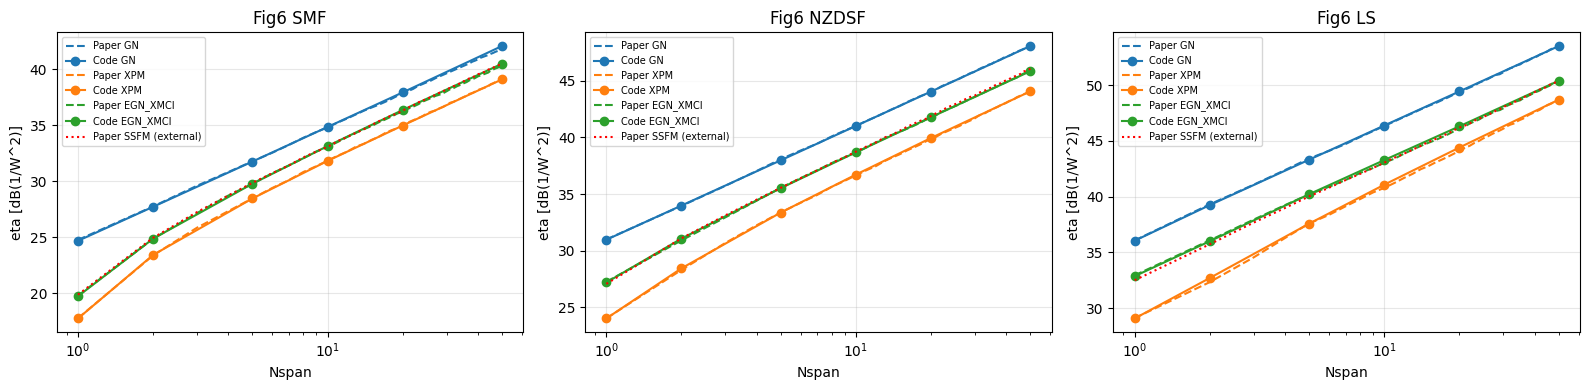

In [9]:
# Dynamic plot: reflects CACHE after RUN_RECOMPUTE, not a stale PNG.
fig_name = 'Fig6'
nch, mapping = FIG_CONFIG[fig_name]
fig, axes = plt.subplots(1,3,figsize=(16,4))
for ax, fiber in zip(axes,FIBERS):
    paper = REF['figures'][fig_name]['curves'][fiber]
    for label in mapping:
        line, = ax.plot(NSPAN,paper[label],'--',label='Paper '+label)
        d = detail[(detail.Fig==fig_name)&(detail.Fiber==fiber)&(detail.Curve==label)]
        ax.plot(d['Nspan'],d['Code [dB]'],'o-',color=line.get_color(),label='Code '+label)
    ax.plot(NSPAN,paper['SIM'],':',color='red',label='Paper SSFM (external)')
    ax.set(xscale='log',xlabel='Nspan',ylabel='eta [dB(1/W^2)]',title=fig_name+' '+fiber)
    ax.grid(alpha=.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


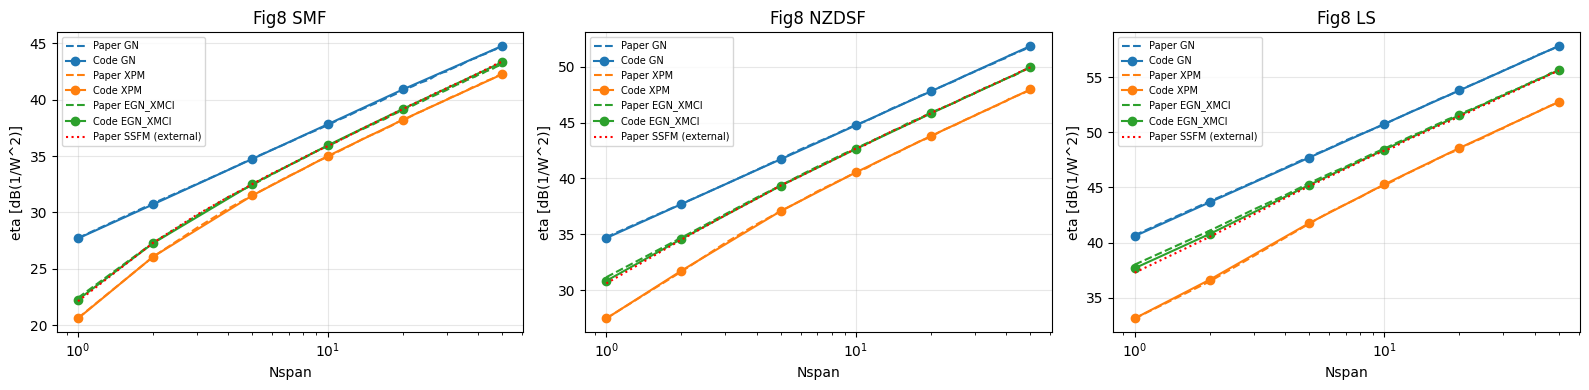

In [10]:
# Dynamic plot: reflects CACHE after RUN_RECOMPUTE, not a stale PNG.
fig_name = 'Fig8'
nch, mapping = FIG_CONFIG[fig_name]
fig, axes = plt.subplots(1,3,figsize=(16,4))
for ax, fiber in zip(axes,FIBERS):
    paper = REF['figures'][fig_name]['curves'][fiber]
    for label in mapping:
        line, = ax.plot(NSPAN,paper[label],'--',label='Paper '+label)
        d = detail[(detail.Fig==fig_name)&(detail.Fiber==fiber)&(detail.Curve==label)]
        ax.plot(d['Nspan'],d['Code [dB]'],'o-',color=line.get_color(),label='Code '+label)
    ax.plot(NSPAN,paper['SIM'],':',color='red',label='Paper SSFM (external)')
    ax.set(xscale='log',xlabel='Nspan',ylabel='eta [dB(1/W^2)]',title=fig_name+' '+fiber)
    ax.grid(alpha=.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


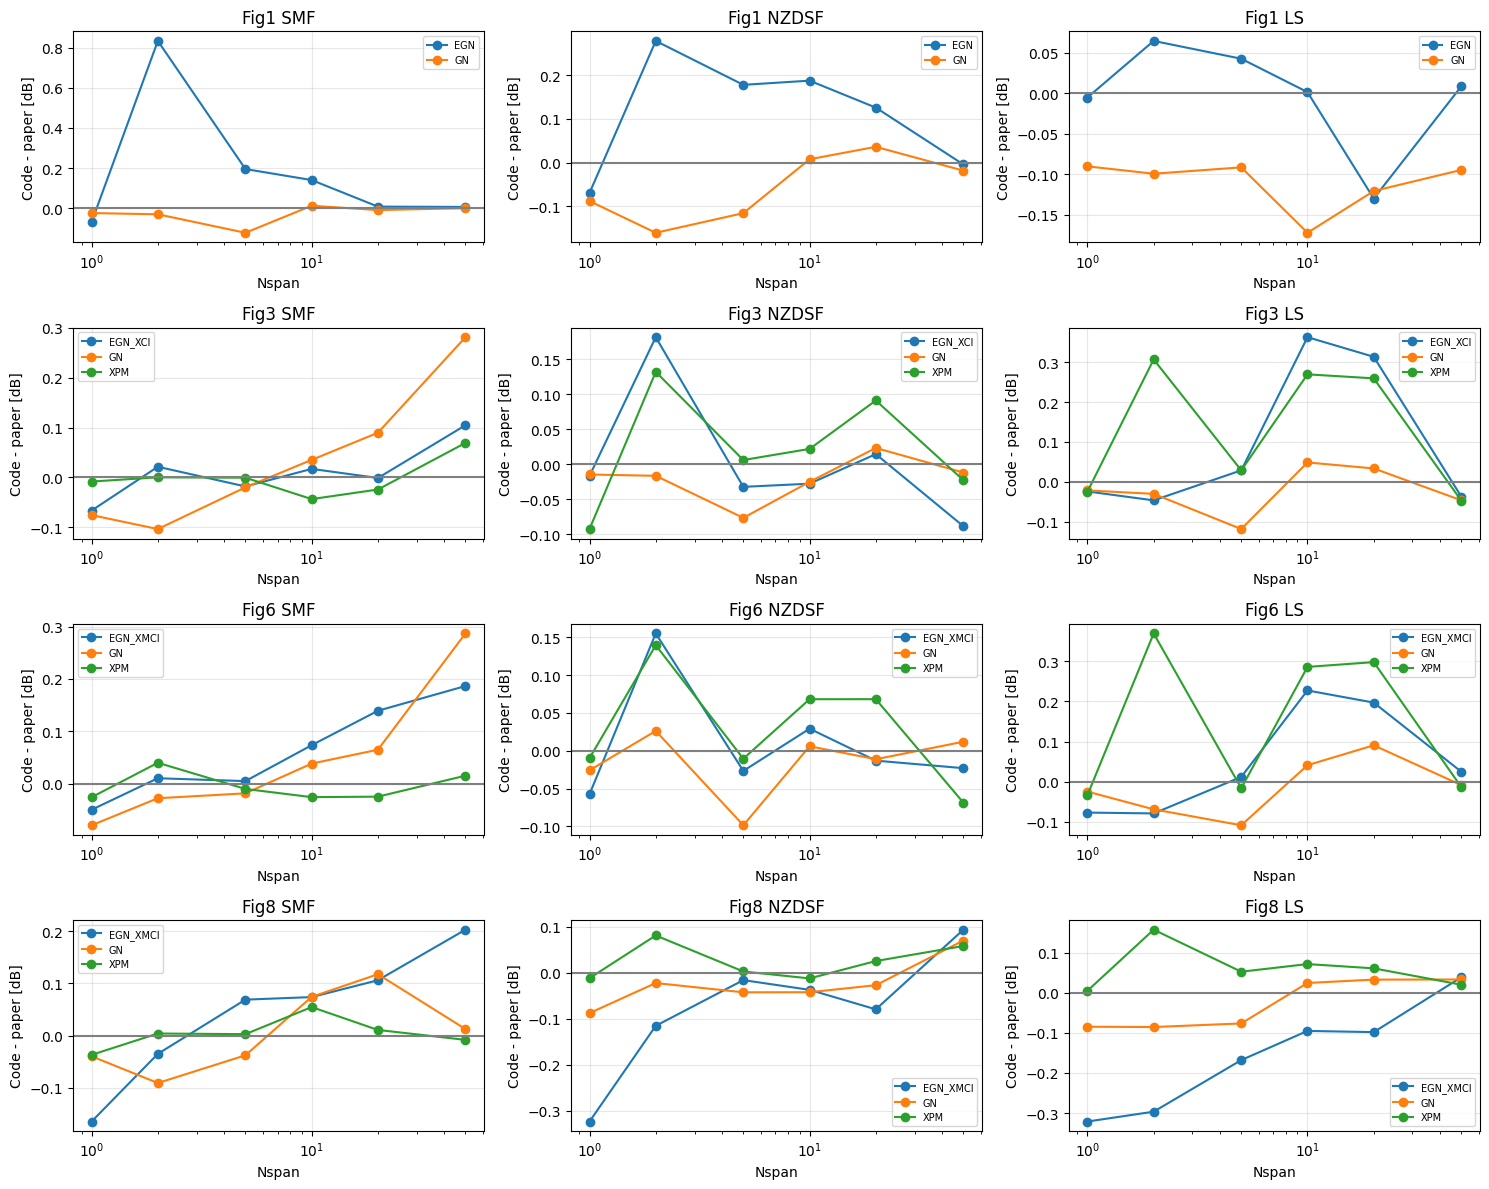

In [11]:
fig, axes = plt.subplots(4,3,figsize=(15,12))
for row, fig_name in enumerate(FIG_CONFIG):
    for col, fiber in enumerate(FIBERS):
        ax=axes[row,col]
        subset=detail[(detail.Fig==fig_name)&(detail.Fiber==fiber)]
        for curve, d in subset.groupby('Curve'):
            ax.plot(d['Nspan'],d['Signed error [dB]'],'o-',label=curve)
        ax.axhline(0,color='grey'); ax.set(xscale='log',title=fig_name+' '+fiber,xlabel='Nspan',ylabel='Code - paper [dB]')
        ax.legend(fontsize=7); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


## Reading the result

- Fig. 1 compares the single-channel SCI terms directly. Its EGN curve is the strongest test of the \(\mu_4,\mu_6\) implementation.
- Fig. 3 compares the three-channel XCI decomposition. The code's XPM and XCI curves are computed from Eqs. (14)–(20), not from a fitted multiplier.
- Fig. 6 adds the Appendix-B MCI correction and compares XMCI= XCI+MCI.
- Fig. 8 repeats the XMCI calculation with four interferers on each side. This is the most demanding check of the generalized MCI terms.

Nonzero theory-to-theory discrepancies can include numerical error, extraction error, and implementation differences. Their separate contributions are not established. SSFM roll-off does not explain a theory-to-theory discrepancy. No fitting was used.

In [12]:
# First 24 rows of the pointwise comparison table
display(detail.head(24).round(4))

,Fig,Fiber,Curve,Nspan,Paper [dB],Code [dB],Signed error [dB],Abs error [dB],Relative error [%]
0,Fig1,SMF,GN,1,22.3644,22.3414,-0.0230,0.0230,0.5275
1,Fig1,SMF,GN,2,26.0893,26.0602,-0.0291,0.0291,0.6672
2,Fig1,SMF,GN,5,31.0417,30.9207,-0.1210,0.1210,2.7474
3,Fig1,SMF,GN,10,34.5280,34.5415,0.0135,0.0135,0.3110
4,Fig1,SMF,GN,20,38.1231,38.1150,-0.0081,0.0081,0.1863
5,Fig1,SMF,GN,50,42.7848,42.7861,0.0013,0.0013,0.0292
6,Fig1,SMF,EGN,1,18.1284,18.0606,-0.0678,0.0678,1.5489
7,Fig1,SMF,EGN,2,22.2264,23.0593,0.8329,0.8329,21.1406
8,Fig1,SMF,EGN,5,28.5615,28.7574,0.1959,0.1959,4.6137
9,Fig1,SMF,EGN,10,32.5967,32.7378,0.1411,0.1411,3.3031


## Reproducibility record

The reference JSON records the PDF page, plot-frame calibration and vector-stroke extraction method. The code cache records fixed quadrature settings and every selected span count. To audit the numbers, set `RUN_RECOMPUTE=True`, rerun the calculation cell, then rerun the table and plot cells. The evaluator refuses non-rectangular spectra, unequal baud/power combs, and off-centre CUTs rather than silently applying formulas outside the paper's scope.

## Final verification and limits

This notebook embeds the exact three Python modules, reference arrays, cache, and plots; GitHub upload is not required. Default execution displays a freshly regenerated fixed-order cache. Set RUN_RECOMPUTE=True to recompute all 54 cases.

Execution verification is performed in a local in-process IPython interpreter, not an authenticated Google Colab session. A separate Jupyter kernel could not start due to network-interface permissions; no permission workaround was used. Colab itself remains untested. Dependencies: numpy, scipy, pandas, matplotlib, IPython.

The new uploaded GN engine and legacy modulation files match this snapshot byte for byte. The uploaded EGN file is SCI-only; this snapshot adds the paper-scope XCI/MCI evaluator.

The largest reported discrepancy (Fig. 1, SMF, 2 spans) is unresolved. SCI eta at frequency quadrature orders 24/48/64/96 with receiver order 7: 23.0593323 / 23.0593154 / 23.0593154 / 23.0593154 dB. At frequency order 64 and receiver orders 7/15/31/61: 23.0593154 / 23.0731645 / 23.0731639 / 23.0731639 dB. Receiver refinement changes the result by +0.01385 dB and does not explain the approximately 0.833 dB discrepancy. Do not attribute it to digitization without further evidence. No fitted parameters or changed cache settings were used.

Reported percentage errors compare linear eta: 100*abs(10**((code_db-paper_db)/10)-1). They are theory-to-theory discrepancies, not SSFM accuracy certification. Reference curves are digitized PDF lines, not author-provided raw data. No general full-EGN accuracy claim is made outside the documented comb assumptions.
